# ĐỀ THI THỰC HÀNH HỌC KỲ 252 – NĂM HỌC 2025–2026  
**Môn:** Thị giác máy tính  
**Trường:** Đại học VĂN LANG  
**Khoa:** CÔNG NGHỆ THÔNG TIN  
**Ngày thi:** 03/04/2026  
**Thời gian:** 120 phút  

> (Được phép sử dụng tài liệu và laptop kết nối mạng)

**Họ tên:** Huỳnh Tấn Phát  
**MSSV:** 2374802010376    
**LỚP:** 0101

## Bài 1 (1 điểm)
Trình bày những nội dung cơ bản của **phép biến đổi Hough**. Lấy ví dụ thực hành (bao gồm code python)

**Phép biến đổi Hough (Hough Transform)** là một kỹ thuật cực kỳ thông minh trong xử lý ảnh, dùng để phát hiện các hình học có thể biểu diễn bằng phương trình toán học (phổ biến nhất là đường thẳng và hình tròn), ngay cả khi chúng bị đứt gãy hoặc nhiễu.

---

Ý tưởng cốt lõi là chuyển bài toán từ **không gian ảnh** $(x, y)$ sang **không gian tham số** (không gian Hough).

* **Phương trình đường thẳng:** Thay vì dùng $y = ax + b$ (dễ bị lỗi khi đường thẳng đứng vì $a \rightarrow \infty$), ta dùng hệ tọa độ cực:
    $$r = x \cdot \cos(\theta) + y \cdot \sin(\theta)$$
    Trong đó:
    * $r$: Khoảng cách từ gốc tọa độ đến đường thẳng.
    * $\theta$: Góc của vector pháp tuyến.

* **Cơ chế bầu chọn (Voting):**
    1.  Mỗi điểm sáng trong ảnh (sau khi lọc cạnh) sẽ "vẽ" ra một đường hình sin trong không gian $(r, \theta)$.
    2.  Nếu nhiều điểm cùng nằm trên một đường thẳng, các đường sin của chúng sẽ giao nhau tại một điểm $(r, \theta)$ duy nhất.
    3.  Điểm giao nhau nào có nhiều "phiếu bầu" nhất chính là đường thẳng cần tìm.


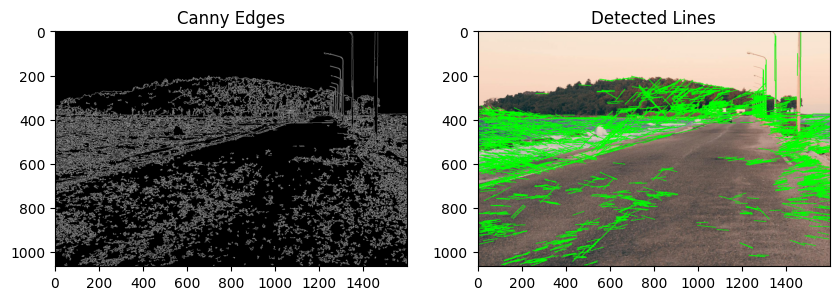

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc ảnh và chuyển sang ảnh xám
img = cv2.imread("road.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Phát hiện cạnh bằng Canny (bắt buộc trước khi dùng Hough)
edges = cv2.Canny(gray, 50, 150, apertureSize=3)

# 3. Áp dụng HoughLinesP (phiên bản xác suất để tối ưu hiệu năng)
# Tham số: (ảnh, độ phân giải r, độ phân giải theta, ngưỡng bầu chọn, độ dài tối thiểu, khoảng cách nối)
lines = cv2.HoughLinesP(
    edges, 1, np.pi / 180, threshold=100, minLineLength=50, maxLineGap=10
)

# 4. Vẽ các đường thẳng tìm được lên ảnh gốc
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.title("Canny Edges")
plt.imshow(edges, cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Detected Lines")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

## Bài 2 (1 điểm)
Trình bày những nội dung cơ bản của phương pháp nhận dạng khuôn mặt **Viola – Jones**. Lấy ví dụ thực hành (bao gồm code python) -Note: Kiểm tra khả năng tự học

Thuật toán này không nhìn vào từng pixel mà nhìn vào sự chênh lệch cường độ sáng thông qua các đặc trưng hình học.

- Haar-like Features: Sử dụng các cửa sổ hình chữ nhật (đen/trắng) để tính toán sự khác biệt giữa các vùng ảnh (ví dụ: vùng mắt thường tối hơn vùng má).

- Integral Image (Ảnh tích phân): Nó cho phép tính tổng pixel trong bất kỳ hình chữ nhật nào chỉ với 4 phép tra cứu, giúp tốc độ tính toán hằng số O(1) bất kể kích thước cửa sổ.

- AdaBoost (Adaptive Boosting): Trong hàng ngàn đặc trưng Haar, AdaBoost lọc ra những đặc trưng "đắt giá" nhất để phân biệt khuôn mặt, loại bỏ những thứ thừa thãi.

- Cascading Classifiers (Bộ phân loại tầng): Thay vì kiểm tra mọi đặc trưng cùng lúc, ảnh đi qua một chuỗi các tầng. Nếu một vùng ảnh trượt ở tầng đầu (chắc chắn không phải mặt), nó bị loại ngay lập tức. Điều này giúp CPU tập trung vào các vùng tiềm năng.

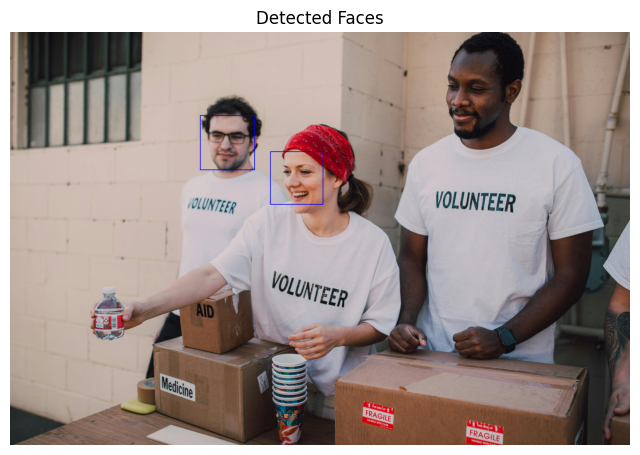

In [14]:
import cv2

# 1. Tải bộ phân loại đã huấn luyện sẵn (Haar Cascade)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# 2. Đọc ảnh và chuyển sang grayscale (Viola-Jones hoạt động trên ảnh xám)
img = cv2.imread("people.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Nhận dạng khuôn mặt
# scaleFactor: Độ giảm kích thước ảnh để quét (1.1 = giảm 10% mỗi lần)
# minNeighbors: Càng cao thì càng ít "báo động giả"
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

# 4. Vẽ khung hình chữ nhật quanh mặt
for x, y, w, h in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 5)

plt.figure(figsize=(8, 6))
plt.title("Detected Faces")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## Bài 3 (1 điểm)
So sánh thuật toán **Meanshift** và **Camshift**. Lấy ví dụ minh họa kèm code python -Note: Kiểm tra khả năng tự học


So sánh Meanshift và Camshift

| Đặc điểm | Meanshift | Camshift (Continuously Adaptive Meanshift) |
| :--- | :--- | :--- |
| **Cửa sổ (Window)** | Kích thước cố định (Fixed size). | Tự động thay đổi kích thước (Adaptive size). |
| **Xoay (Rotation)** | Không theo dõi được góc xoay của vật thể. | Theo dõi được hướng (orientation) và góc xoay. |
| **Ứng dụng** | Phù hợp vật thể không đổi kích thước/khoảng cách. | Phù hợp vật thể di chuyển tiến/lùi hoặc xoay. |
| **Đầu ra** | Tâm của cửa sổ ($x, y$). | Tâm ($x, y$), kích thước ($w, h$) và góc xoay ($\alpha$). |



**Bản chất:** Camshift thực hiện Meanshift trước, sau đó cập nhật kích thước cửa sổ dựa trên mô-men bậc nhất (zeroth moment) của vùng điểm ảnh tìm được.


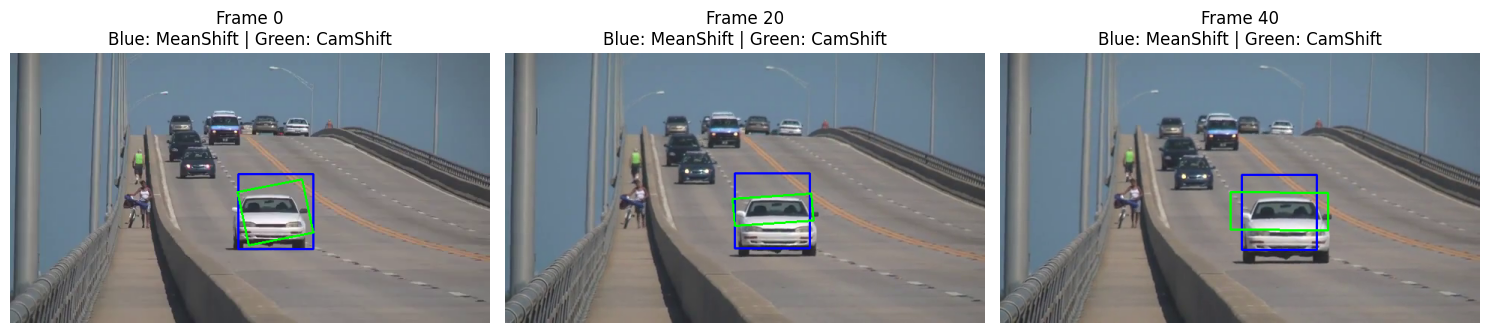

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1) Input video
video_path = "slow_traffic_small.mp4"  # doi ten file neu can
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise FileNotFoundError(f"Khong mo duoc video: {video_path}")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
if total_frames <= 0:
    raise ValueError("Video khong hop le hoac khong doc duoc so frame")
if total_frames <= 10:
    raise ValueError("Video can it nhat 11 frame de lay frame 0, 5, 10")

# 2) Doc frame dau de chon ROI ban dau
ret, first_frame = cap.read()
if not ret:
    raise ValueError("Khong doc duoc frame dau tien")

# ROI vi du (ban co the chinh lai theo doi tuong that)
x, y, w, h = 300, 200, 100, 100
track_window_ms = (x, y, w, h)
track_window_cs = (x, y, w, h)

roi = first_frame[y : y + h, x : x + w]
hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(
    hsv_roi, np.array((0.0, 60.0, 32.0)), np.array((180.0, 255.0, 255.0))
)
roi_hist = cv2.calcHist([hsv_roi], [0], mask, [180], [0, 180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)

term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

# 3) Chi lay output tai 3 frame
target_ids = [0, 20, 40]
saved_frames = {}
current_idx = 0

# Xu ly frame dau tien
hsv = cv2.cvtColor(first_frame, cv2.COLOR_BGR2HSV)
back_proj = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)
_, track_window_ms = cv2.meanShift(back_proj, track_window_ms, term_crit)
ret_cs, track_window_cs = cv2.CamShift(back_proj, track_window_cs, term_crit)

vis = first_frame.copy()
x_ms, y_ms, w_ms, h_ms = track_window_ms
cv2.rectangle(vis, (x_ms, y_ms), (x_ms + w_ms, y_ms + h_ms), (255, 0, 0), 2)
pts = cv2.boxPoints(ret_cs)
pts = np.intp(pts)
cv2.polylines(vis, [pts], True, (0, 255, 0), 2)
if current_idx in target_ids:
    saved_frames[current_idx] = vis

# 4) Chay video va luu frame
while True:
    ret, frame = cap.read()
    if not ret:
        break
    current_idx += 1

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    back_proj = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)

    _, track_window_ms = cv2.meanShift(back_proj, track_window_ms, term_crit)
    ret_cs, track_window_cs = cv2.CamShift(back_proj, track_window_cs, term_crit)

    if current_idx in target_ids:
        vis = frame.copy()
        x_ms, y_ms, w_ms, h_ms = track_window_ms
        cv2.rectangle(vis, (x_ms, y_ms), (x_ms + w_ms, y_ms + h_ms), (255, 0, 0), 2)
        pts = cv2.boxPoints(ret_cs)
        pts = np.intp(pts)
        cv2.polylines(vis, [pts], True, (0, 255, 0), 2)
        saved_frames[current_idx] = vis

    if current_idx >= target_ids[-1]:
        break

cap.release()

# 5) Hien thi dung 3 frame
frames_to_show = [saved_frames[i] for i in target_ids if i in saved_frames]
labels = [f"Frame {i}" for i in target_ids if i in saved_frames]

if len(frames_to_show) < 3:
    raise ValueError("Khong lay duoc du 3 frame")

plt.figure(figsize=(15, 5))
for i, (img, label) in enumerate(zip(frames_to_show, labels), start=1):
    plt.subplot(1, 3, i)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(label + "\nBlue: MeanShift | Green: CamShift")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Bài 4 (2 điểm)

Cho ảnh 3-bit kích thước $5 \times 5$, bộ lọc thông thấp và bộ lọc Laplacian như hình vẽ.

Thực hiện tại điểm ảnh $(2,1)$ cho ảnh gốc, xác định:

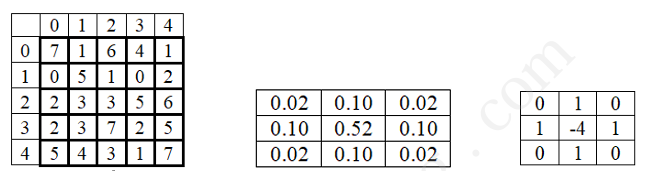

a. Giá trị sau khi áp dụng bộ lọc trung bình $3 \times 3$  
b. Giá trị sau khi áp dụng bộ lọc trung vị $3 \times 3$  
c. Giá trị sau khi áp dụng bộ lọc Laplacian  
d. Giá trị sau khi áp dụng bộ lọc thông thấp  
e. Xác định $dx, dy$  
f. Vẽ histogram của ảnh gốc  
g. Xác định ảnh sau khi cân bằng histogram

--- Kết quả tại điểm (2, 1) ---
a. Trung bình: 2.89
b. Trung vị: 3.0
c. Laplacian: 1
d. Thông thấp: 3.06
e. dx = 0, dy = 0


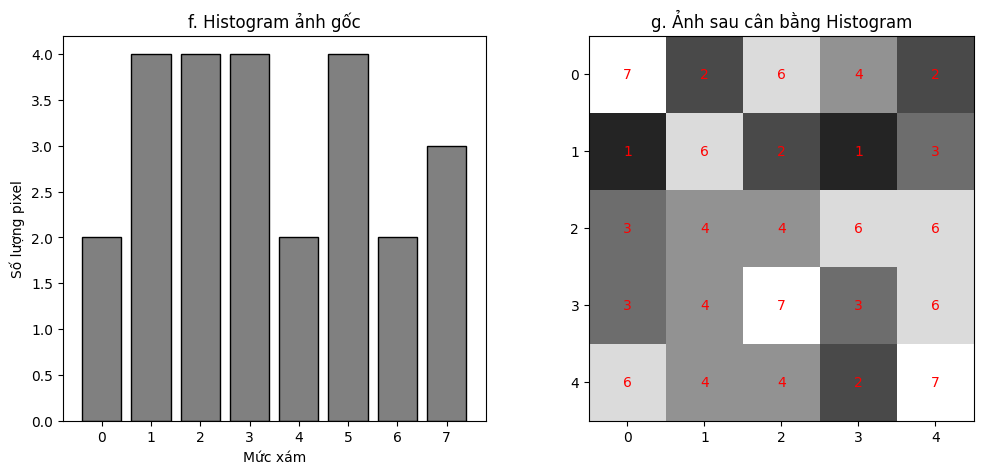


g. Ma trận sau khi cân bằng Histogram:
[[7 2 6 4 2]
 [1 6 2 1 3]
 [3 4 4 6 6]
 [3 4 7 3 6]
 [6 4 4 2 7]]


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Khởi tạo ma trận ảnh gốc (5x5)
img = np.array(
    [
        [7, 1, 6, 4, 1],
        [0, 5, 1, 0, 2],
        [2, 3, 3, 5, 6],
        [2, 3, 7, 2, 5],
        [5, 4, 3, 1, 7],
    ]
)

# Điểm ảnh mục tiêu: (r, c) = (2, 1) -> giá trị là 3
r, c = 2, 1
# Trích xuất vùng lân cận 3x3 xung quanh (2, 1)
neighborhood = img[r - 1 : r + 2, c - 1 : c + 2]

# a. Bộ lọc trung bình 3x3
mean_val = np.mean(neighborhood)

# b. Bộ lọc trung vị 3x3
median_val = np.median(neighborhood)

# c. Bộ lọc Laplacian (kernel trong hình)
laplacian_kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
laplacian_val = np.sum(neighborhood * laplacian_kernel)

# d. Bộ lọc thông thấp (kernel thập phân trong hình)
lowpass_kernel = np.array([[0.02, 0.10, 0.02], [0.10, 0.52, 0.10], [0.02, 0.10, 0.02]])
lowpass_val = np.sum(neighborhood * lowpass_kernel)

# e. Xác định dx, dy (sử dụng sai phân hữu hạn tại (2, 1))
# dx = img(r, c+1) - img(r, c) | dy = img(r+1, c) - img(r, c)
dx = int(img[r, c + 1]) - int(img[r, c])
dy = int(img[r + 1, c]) - int(img[r, c])

print(f"--- Kết quả tại điểm (2, 1) ---")
print(f"a. Trung bình: {mean_val:.2f}")
print(f"b. Trung vị: {median_val}")
print(f"c. Laplacian: {laplacian_val}")
print(f"d. Thông thấp: {lowpass_val:.2f}")
print(f"e. dx = {dx}, dy = {dy}")

# f. Vẽ Histogram ảnh gốc (3-bit nên mức xám từ 0-7)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
hist, bins = np.histogram(img.flatten(), bins=range(9))
plt.bar(range(8), hist, color="gray", edgecolor="black")
plt.title("f. Histogram ảnh gốc")
plt.xlabel("Mức xám")
plt.ylabel("Số lượng pixel")

# g. Cân bằng Histogram (Histogram Equalization)
# 1. Tính CDF
hist_norm = hist / img.size
cdf = hist_norm.cumsum()
# 2. Map mức xám: round(cdf * (L-1)) với L=8
mapping = np.round(cdf * 7).astype(int)
img_equalized = mapping[img]

plt.subplot(1, 2, 2)
plt.imshow(img_equalized, cmap="gray", vmin=0, vmax=7)
for i in range(5):
    for j in range(5):
        plt.text(j, i, str(img_equalized[i, j]), ha="center", va="center", color="red")
plt.title("g. Ảnh sau cân bằng Histogram")
plt.show()

print("\ng. Ma trận sau khi cân bằng Histogram:")
print(img_equalized)

## Bài 5 (1 điểm)

Cho ảnh nhị phân kích thước $6 \times 6$, trong đó các ô trống có giá trị 0.

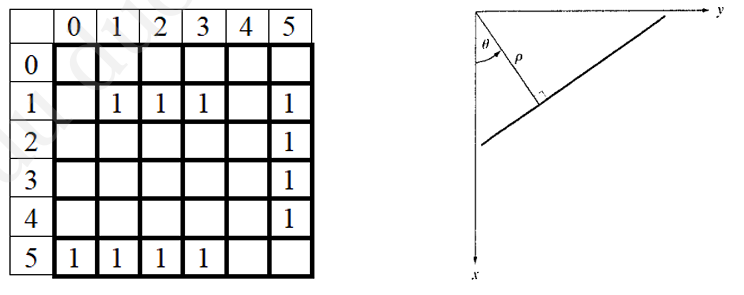

Xác định ma trận **accumulator cell**  $A(\rho,\theta)$. 
(xét các giá trị $\rho$ thích hợp và $\theta = 0^o, 45^o, 90^o$ ).

In [8]:
import numpy as np
import pandas as pd

# 1. Khởi tạo ma trận ảnh nhị phân 6x6
# 1 đại diện cho điểm ảnh trắng, 0 là ô trống
img = np.zeros((6, 6), dtype=int)
img[1, [1, 2, 3, 5]] = 1
img[2, 5] = 1
img[3, 5] = 1
img[4, 5] = 1
img[5, [0, 1, 2, 3]] = 1

# 2. Thiết lập các giá trị theta (chuyển sang radian)
thetas = np.array([0, 45, 90])
thetas_rad = np.deg2rad(thetas)

# Tìm các tọa độ (x, y) có giá trị là 1
x_coords, y_coords = np.where(img == 1)

# 3. Tính toán các giá trị rho cho mỗi điểm ảnh ứng với mỗi theta
# Kết quả rho có thể là số thực, ta làm tròn để đưa vào accumulator cell
accumulator_data = []

for x, y in zip(x_coords, y_coords):
    for theta, rad in zip(thetas, thetas_rad):
        rho = x * np.cos(rad) + y * np.sin(rad)
        # Làm tròn rho đến 1 chữ số thập phân hoặc số nguyên tùy quy ước
        # Ở đây dùng round để dễ quan sát nhóm
        accumulator_data.append({"x": x, "y": y, "theta": theta, "rho": round(rho, 2)})

df = pd.DataFrame(accumulator_data)

# 4. Tạo ma trận Accumulator (Pivot table để đếm số phiếu bầu)
accumulator_cell = df.groupby(["rho", "theta"]).size().unstack(fill_value=0)

print("Ma trận Accumulator Cell A(rho, theta):")
print("-" * 40)
print(accumulator_cell)

# 5. Tìm đường thẳng nổi bật nhất (nhiều phiếu bầu nhất)
max_votes = accumulator_cell.values.max()
best_lines = np.where(accumulator_cell == max_votes)
print("\n" + "=" * 40)
print(f"Số phiếu bầu cao nhất: {max_votes}")
for i in range(len(best_lines[0])):
    r_idx = best_lines[0][i]
    c_idx = best_lines[1][i]
    print(
        f"Đường thẳng tiềm năng: rho = {accumulator_cell.index[r_idx]}, theta = {accumulator_cell.columns[c_idx]}°"
    )

Ma trận Accumulator Cell A(rho, theta):
----------------------------------------
theta  0   45  90
rho              
0.00    0   0   1
1.00    4   0   2
1.41    0   1   0
2.00    1   0   2
2.12    0   1   0
2.83    0   1   0
3.00    1   0   2
3.54    0   1   0
4.00    1   0   0
4.24    0   2   0
4.95    0   2   0
5.00    4   0   4
5.66    0   2   0
6.36    0   1   0

Số phiếu bầu cao nhất: 4
Đường thẳng tiềm năng: rho = 1.0, theta = 0°
Đường thẳng tiềm năng: rho = 5.0, theta = 0°
Đường thẳng tiềm năng: rho = 5.0, theta = 90°


## Bài 6 (1.5 điểm)
Cho ảnh (bên trái) và **structuring element (SE)** (gốc tọa độ trùng với tâm SE).

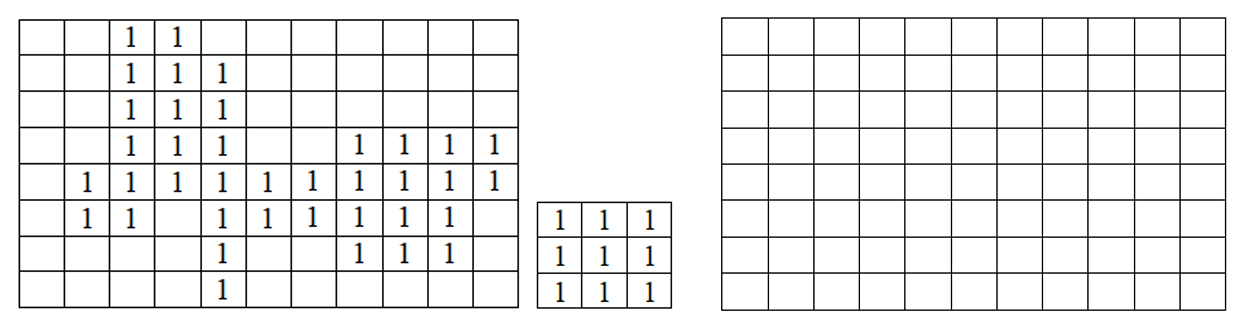

Thực hiện:
- Dilation
- Sau đó Erosion

Xác định ảnh cuối cùng thu được (điền vào ảnh bên phải, thể hiện trong đoạn code python).

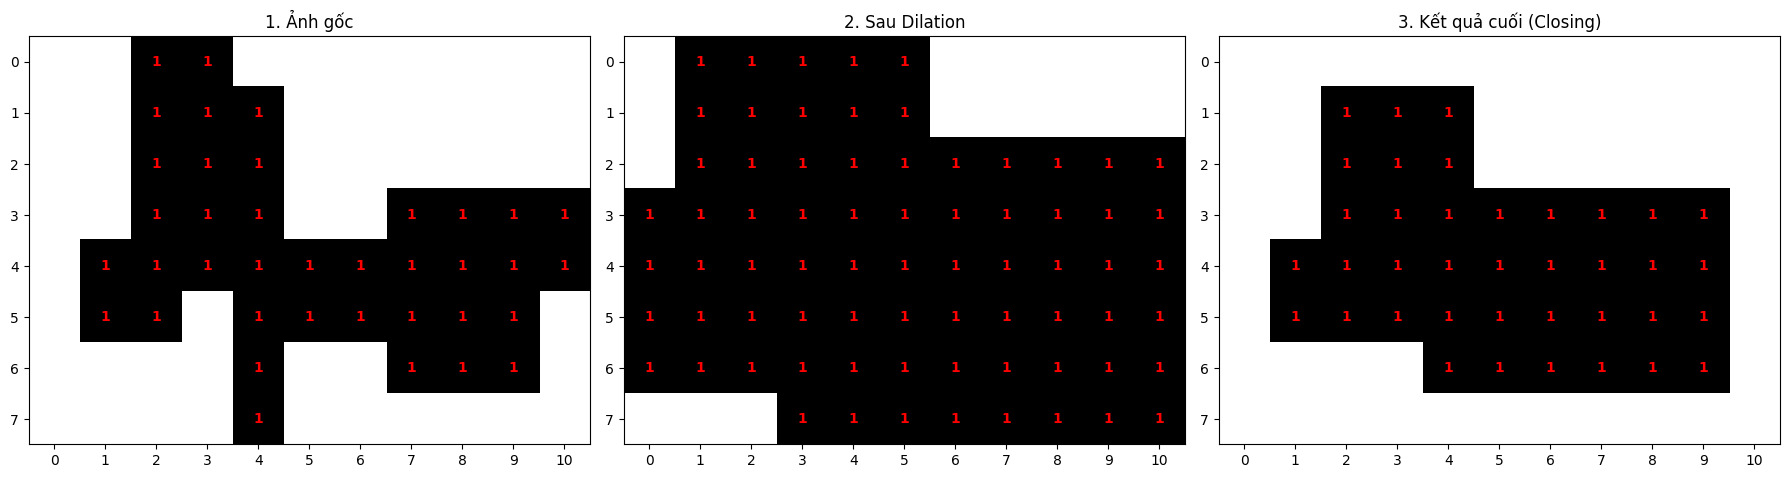

Ma trận kết quả cuối cùng:
[[0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 0 0 0 0 0 0]
 [0 0 1 1 1 0 0 0 0 0 0]
 [0 0 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 0 0 0 1 1 1 1 1 1 0]
 [0 0 0 0 0 0 0 0 0 0 0]]


In [11]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

# 1. Khởi tạo ảnh gốc (8 hàng x 11 cột dựa trên hình vẽ)
# 1 là điểm ảnh trắng, 0 là ô trống
img = np.array(
    [
        [0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0],
        [0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    ]
)

# 2. Khởi tạo Structuring Element (SE) 3x3 toàn 1, gốc tọa độ ở tâm
se = np.ones((3, 3), dtype=int)

# 3. Thực hiện Dilation (Nở rẽ)
dilation_img = ndimage.binary_dilation(img, structure=se).astype(int)

# 4. Thực hiện Erosion (Bào mòn) trên kết quả của Dilation
final_img = ndimage.binary_erosion(dilation_img, structure=se).astype(int)


# --- Hiển thị kết quả ---
def plot_matrix(matrix, title, subplot_pos):
    plt.subplot(1, 3, subplot_pos)
    plt.imshow(matrix, cmap="gray_r")
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            if matrix[i, j] == 1:
                plt.text(
                    j, i, "1", ha="center", va="center", color="red", weight="bold"
                )
    plt.title(title)
    plt.xticks(range(11))
    plt.yticks(range(8))


plt.figure(figsize=(18, 6))
plot_matrix(img, "1. Ảnh gốc", 1)
plot_matrix(dilation_img, "2. Sau Dilation", 2)
plot_matrix(final_img, "3. Kết quả cuối (Closing)", 3)
plt.tight_layout()
plt.show()

print("Ma trận kết quả cuối cùng:")
print(final_img)

## Bài 7 (1.5 điểm)

Cho mạng CNN như hình vẽ.

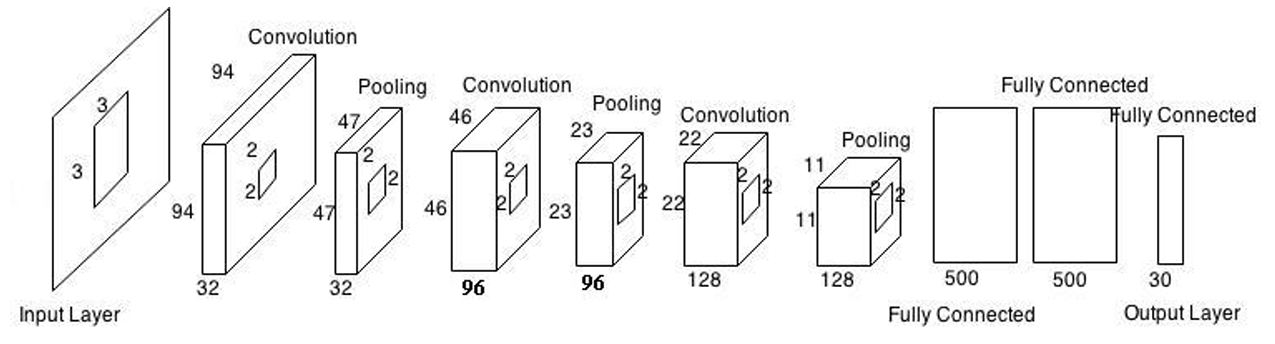

a. Có những loại lớp (layer) nào? Số lượng mỗi loại?  

b. Ảnh đầu vào có kích thước bao nhiêu?  
- Biết stride $S = 1$, số zero-padding $P = 0$  
- Ảnh màu hay ảnh xám?  

c. Lớp tích chập thứ hai:
- Có bao nhiêu kernel?  
- Kích thước mỗi kernel?  
- Tổng số tham số?  

d. Mạng có thể dùng để phân loại 35 loài động vật hay không? Tại sao?

## Trả lời bài 7:
### a. Có những loại lớp (layer) nào? Số lượng mỗi loại?

Dựa trên sơ đồ, mạng CNN này bao gồm các loại lớp sau:
* **Input Layer:** 01 lớp (Ảnh đầu vào).
* **Convolution Layer (Lớp tích chập):** 03 lớp.
* **Pooling Layer (Lớp gộp):** 03 lớp (thường là Max Pooling hoặc Average Pooling).
* **Fully Connected Layer (Lớp kết nối đầy đủ):** 03 lớp (bao gồm 2 lớp ẩn 500 node và 1 lớp Output 30 node).

---

### b. Ảnh đầu vào có kích thước bao nhiêu?

Để xác định kích thước ảnh đầu vào, ta dựa vào lớp Convolution đầu tiên.
* **Kích thước Feature Map sau Conv1:** $94 \times 94 \times 32$.
* **Kernel size của Conv1:** $3 \times 3$ (nhìn vào ô vuông nhỏ ở lớp Input).
* **Công thức:** $W_{out} = \frac{W_{in} - F + 2P}{S} + 1$. 
    * Với $S=1, P=0, F=3, W_{out}=94$: 
    * $94 = \frac{W_{in} - 3 + 0}{1} + 1 \Rightarrow W_{in} = 96$.
* **Số kênh (Channels):** Nhìn vào lớp Input, ta không thấy độ sâu (depth) được ghi rõ như các lớp sau (32, 96, 128), nhưng thông thường ảnh màu sẽ có 3 kênh (RGB). Tuy nhiên, nếu xét thuần túy theo toán học tích chập để tạo ra 32 feature maps đầu tiên, lớp Input có thể là **ảnh xám (1 kênh)** hoặc **ảnh màu (3 kênh)** tùy thuộc vào thiết kế kernel. 
* **Kết luận:** Ảnh đầu vào có kích thước **$96 \times 96$**. Đây khả năng cao là **ảnh màu** (do kiến trúc khá sâu và phức tạp), nhưng về mặt dữ liệu hiển thị trên hình, ta chỉ xác định chắc chắn được $96 \times 96$.

---

### c. Lớp tích chập thứ hai (Convolution 2):

Lớp này nằm giữa Pooling 1 ($47 \times 47 \times 32$) và Pooling 2 ($23 \times 23 \times 96$).

* **Số lượng kernel:** Bằng số lượng feature maps ở đầu ra của lớp đó $\Rightarrow$ **96 kernel**.
* **Kích thước mỗi kernel:** Nhìn vào ô vuông ở lớp Convolution trước đó, kích thước không gian là $2 \times 2$ (hoặc tính toán từ $W_{in}=47, W_{out}=46, S=1, P=0 \Rightarrow F = 47 - 46 + 1 = 2$).
    * Độ sâu của kernel phải khớp với số kênh đầu vào ($32$).
    * Vậy kích thước mỗi kernel là **$2 \times 2 \times 32$**.
* **Tổng số tham số (Weights + Bias):**
    * Số lượng trọng số (weights): $2 \times 2 \times 32 \times 96 = 12,288$.
    * Số lượng độ lệch (bias): $96$.
    * **Tổng cộng:** $12,288 + 96 = \mathbf{12,384}$ tham số.

---

### d. Mạng có thể dùng để phân loại 35 loài động vật hay không? Tại sao?

* **Trả lời:** **Không.**
* **Tại sao:** Vì lớp **Output Layer** (lớp cuối cùng bên phải) chỉ có **30 node** (được ghi số 30 ở dưới). Trong bài toán phân loại (classification), số lượng node ở lớp cuối phải tương ứng với số lượng lớp (classes) cần phân loại. Với 30 node, mạng này chỉ có thể phân loại tối đa 30 đối tượng khác nhau.

## Bài 8 (1 điểm)

Cho mạng CNN thỏa:

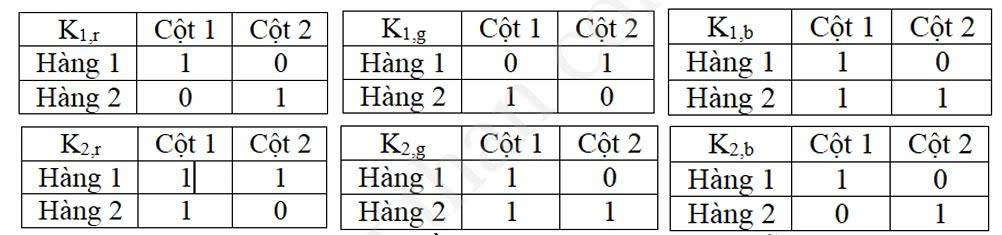

- Lớp đầu tiên là convolution
- Stride $S = 1$, zero-padding $P = 0$
- Có 2 kernel $K_1, K_2$

Ngõ vào $I$ của mạng CNN là:
- Ảnh màu gồm 3 kênh $I_r, I_g, I_b$
- Mỗi kênh kích thước $3 \times 3$

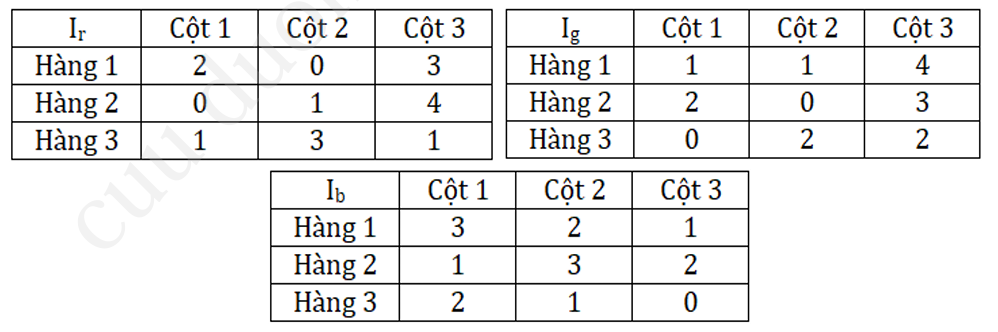

Yêu cầu:
- Xác định các activation map, biết mạng sử dụng hàm ReLU và $bias_1 = -14$, $bias_2 = -10$

> Lưu ý: Có thể tự đưa thêm giả thiết nếu cần.

### Lời giải Bài 8 (theo giả thiết từ hình)

Với stride $S=1$, padding $P=0$, input kích thước $3\times3\times3$ và kernel kích thước $2\times2\times3$ nên mỗi kernel cho ra activation map kích thước $2\times2$.

Áp dụng công thức:
$$Z = \sum(I\odot K) + b,\quad A = \mathrm{ReLU}(Z)=\max(0,Z)$$

Kết quả thu được:
- Với $K_1,\; b_1=-14$:
$$A_1=\begin{bmatrix}0 & 1\\0 & 0\end{bmatrix}$$
- Với $K_2,\; b_2=-10$:
$$A_2=\begin{bmatrix}1 & 2\\0 & 5\end{bmatrix}$$

In [13]:
import numpy as np


def relu(x):
    return np.maximum(0, x)


# Input 3x3x3 (Ir, Ig, Ib)
Ir = np.array([[2, 0, 3], [0, 1, 4], [1, 3, 1]])
Ig = np.array([[1, 1, 4], [2, 0, 3], [0, 2, 2]])
Ib = np.array([[3, 2, 1], [1, 3, 2], [2, 1, 0]])
I = np.stack([Ir, Ig, Ib], axis=-1)  # (H, W, C)

# 2 kernel 2x2x3 (theo giả thiết từ hình)
K1 = np.stack([[[1, 0], [0, 1]], [[0, 1], [1, 0]], [[1, 0], [1, 1]]], axis=-1)
K2 = np.stack([[[1, 1], [1, 0]], [[1, 0], [1, 1]], [[1, 0], [0, 1]]], axis=-1)
b1, b2 = -14, -10


def conv2d_valid_with_relu(img, kernel, bias):
    h, w, _ = img.shape
    kh, kw, _ = kernel.shape
    out_h, out_w = h - kh + 1, w - kw + 1

    z = np.zeros((out_h, out_w), dtype=int)
    a = np.zeros((out_h, out_w), dtype=int)

    for r in range(out_h):
        for c in range(out_w):
            region = img[r : r + kh, c : c + kw, :]
            z[r, c] = int(np.sum(region * kernel) + bias)
            a[r, c] = int(relu(z[r, c]))
    return z, a


Z1, A1 = conv2d_valid_with_relu(I, K1, b1)
Z2, A2 = conv2d_valid_with_relu(I, K2, b2)

print("Pre-activation Z1 (truoc ReLU):\n", Z1)
print("Activation map A1 (sau ReLU):\n", A1)
print()
print("Pre-activation Z2 (truoc ReLU):\n", Z2)
print("Activation map A2 (sau ReLU):\n", A2)

Pre-activation Z1 (truoc ReLU):
 [[-1  1]
 [-7 -3]]
Activation map A1 (sau ReLU):
 [[0 1]
 [0 0]]

Pre-activation Z2 (truoc ReLU):
 [[ 1  2]
 [-2  5]]
Activation map A2 (sau ReLU):
 [[1 2]
 [0 5]]
